In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("data/interim")
R_DIR = BASE_DIR / "r_outputs"

submission_files = {
    "R_stepAIC": R_DIR / "submission_stepAIC_both.csv",
    "Py_best_single": BASE_DIR / "python_submission_best_single_model.csv",
    "Py_tuned_v2": BASE_DIR / "python_submission_manual_tuned_v2.csv",
    # "Py_blend_v2b": BASE_DIR / "python_submission_manual_tuned_blend_v2b.csv",
}

subs = {}
for name, path in submission_files.items():
    df = pd.read_csv(path)
    df = df.sort_values("ID").reset_index(drop=True)
    subs[name] = df
    print(name, df.shape, path)

# sanity check: identyczna kolejność ID
ref_name = list(subs.keys())[0]
ref_ids = subs[ref_name]["ID"]

for name, df in subs.items():
    same_ids = ref_ids.equals(df["ID"])
    print(f"{name}: same ID order as {ref_name}? {same_ids}")

R_stepAIC (132133, 2) data\interim\r_outputs\submission_stepAIC_both.csv
Py_best_single (132133, 2) data\interim\python_submission_best_single_model.csv
Py_tuned_v2 (132133, 2) data\interim\python_submission_manual_tuned_v2.csv
R_stepAIC: same ID order as R_stepAIC? True
Py_best_single: same ID order as R_stepAIC? True
Py_tuned_v2: same ID order as R_stepAIC? True


In [3]:
merged = pd.DataFrame({"ID": subs[ref_name]["ID"]})

for name, df in subs.items():
    merged[name] = df["Pred"].values

print(merged.shape)
display(merged.head())

(132133, 4)


,ID,R_stepAIC,Py_best_single,Py_tuned_v2
0,2026_1101_1102,0.717933,0.126845,0.602113
1,2026_1101_1103,0.098485,0.039410,0.215156
2,2026_1101_1104,0.024421,0.020793,0.046490
3,2026_1101_1105,0.740742,0.700199,0.753934
4,2026_1101_1106,0.777583,0.570228,0.635583


In [4]:
summary = []

for col in merged.columns[1:]:
    s = merged[col]
    summary.append({
        "model": col,
        "min": s.min(),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "mean": s.mean(),
        "median": s.median(),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "max": s.max(),
        "std": s.std(),
    })

summary_df = pd.DataFrame(summary).sort_values("model").reset_index(drop=True)
display(summary_df)

,model,min,q01,q05,mean,median,q95,q99,max,std
0,Py_best_single,0.000067,0.020400,0.059329,0.500037,0.495007,0.945122,0.984516,0.999876,0.286089
1,Py_tuned_v2,0.002371,0.032647,0.080391,0.495609,0.492316,0.910328,0.968274,0.997542,0.258872
2,R_stepAIC,0.000142,0.006820,0.029881,0.487549,0.478854,0.966394,0.992445,0.999869,0.313463


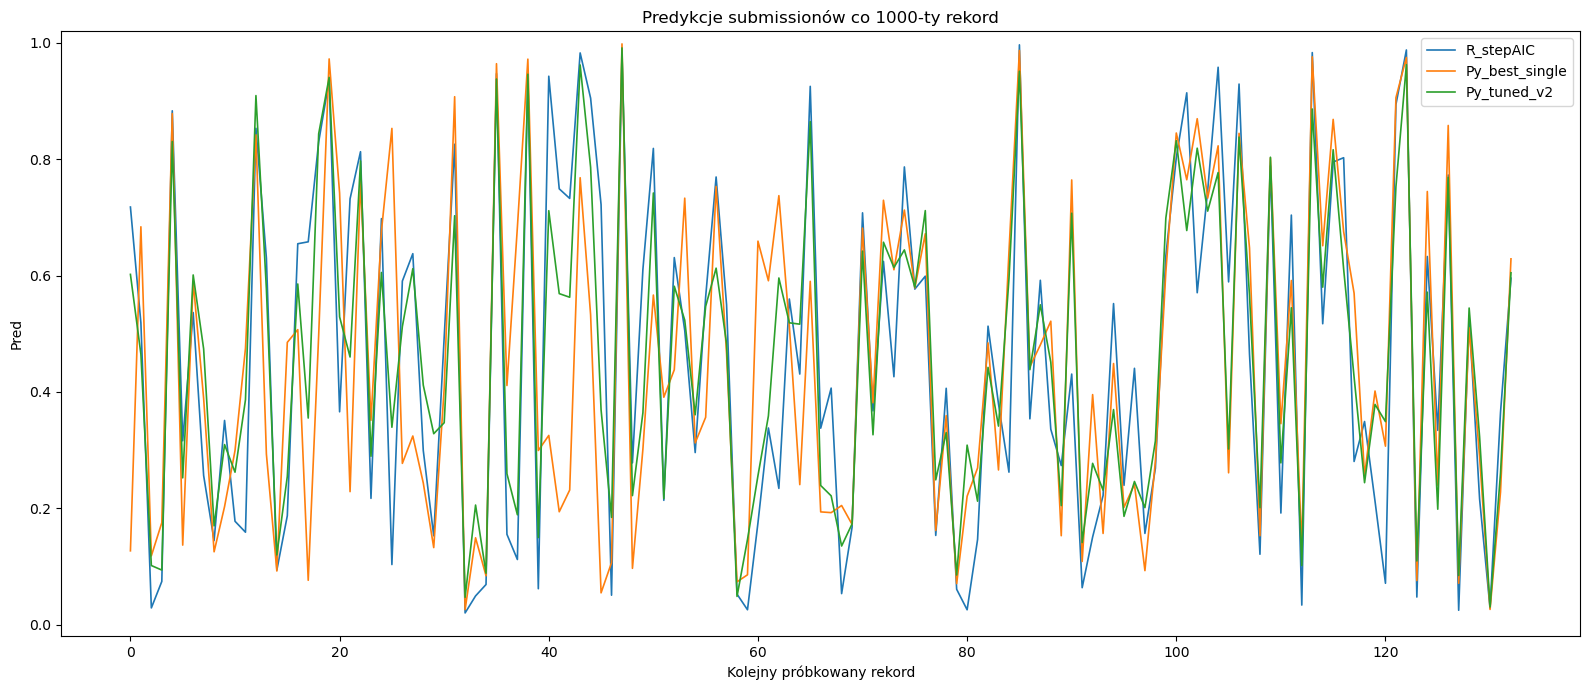

In [10]:
step = 1000  # możesz zmienić np. na 50 albo 200

plot_df = merged.iloc[::step].copy()
plot_df["idx"] = np.arange(len(plot_df))

plt.figure(figsize=(16, 7))

for col in merged.columns[1:]:
    plt.plot(plot_df["idx"], plot_df[col], linewidth=1.2, label=col)

plt.title(f"Predykcje submissionów co {step}-ty rekord")
plt.xlabel("Kolejny próbkowany rekord")
plt.ylabel("Pred")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

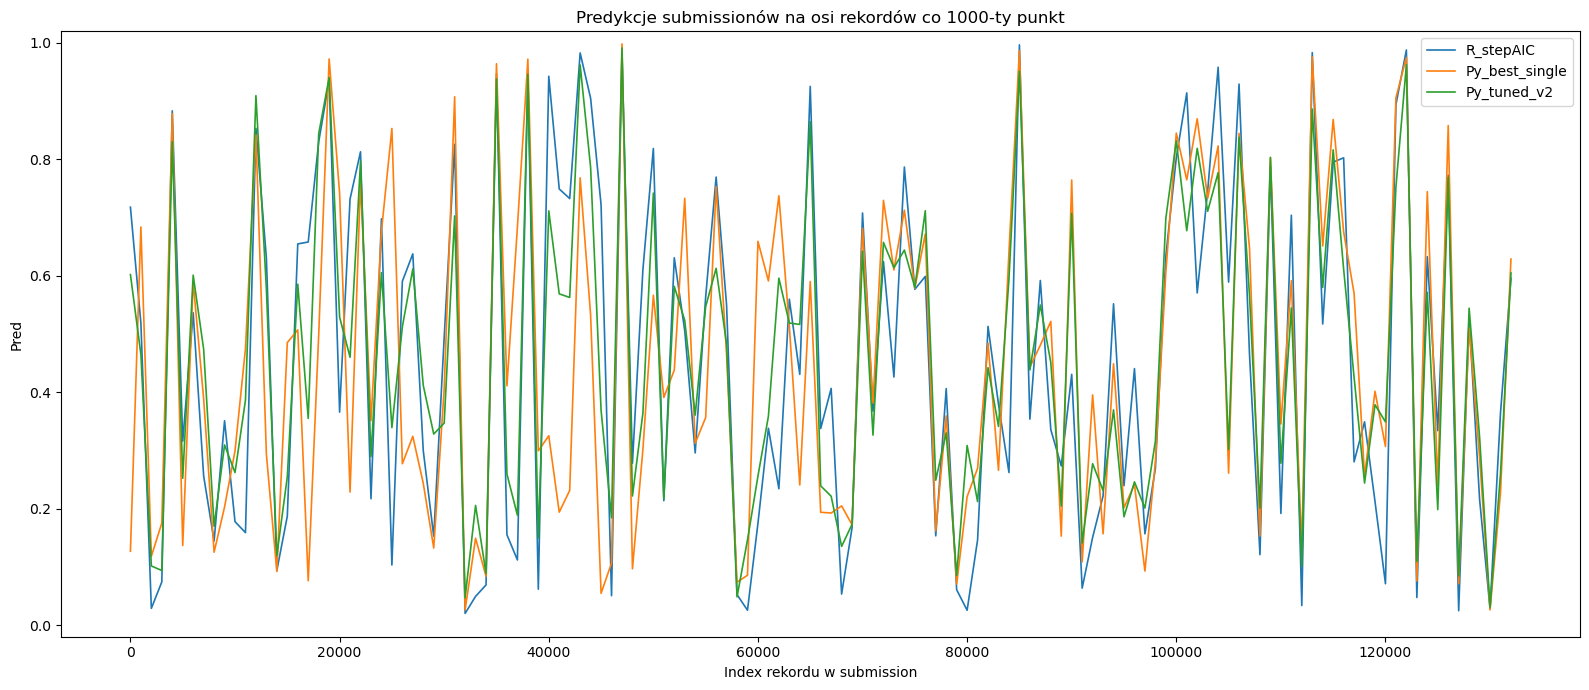

In [11]:
plot_df = merged.iloc[::step].copy()
plot_df["orig_idx"] = plot_df.index

plt.figure(figsize=(16, 7))

for col in merged.columns[1:]:
    plt.plot(plot_df["orig_idx"], plot_df[col], linewidth=1.2, label=col)

plt.title(f"Predykcje submissionów na osi rekordów co {step}-ty punkt")
plt.xlabel("Index rekordu w submission")
plt.ylabel("Pred")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

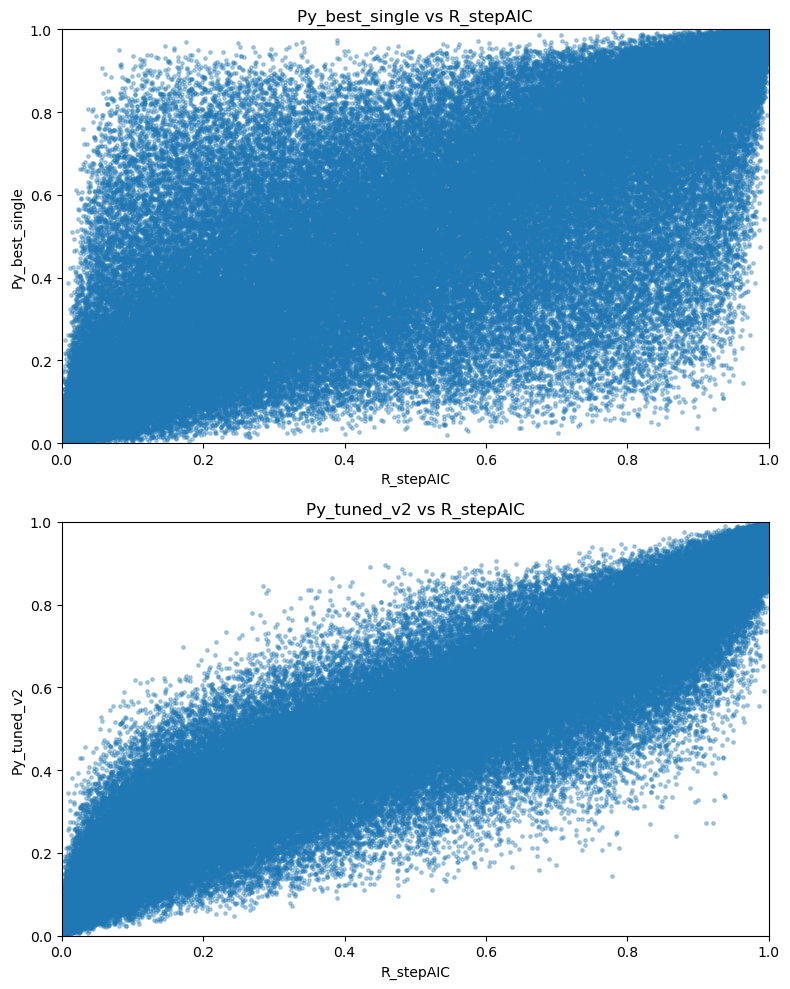

In [7]:
reference_model = "R_stepAIC"

other_models = [c for c in merged.columns[1:] if c != reference_model]

fig, axes = plt.subplots(len(other_models), 1, figsize=(8, 5 * len(other_models)))
if len(other_models) == 1:
    axes = [axes]

for ax, col in zip(axes, other_models):
    ax.scatter(merged[reference_model], merged[col], s=6, alpha=0.35)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{col} vs {reference_model}")
    ax.set_xlabel(reference_model)
    ax.set_ylabel(col)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [8]:
diff_summary = []

model_cols = list(merged.columns[1:])

for i in range(len(model_cols)):
    for j in range(i + 1, len(model_cols)):
        a = model_cols[i]
        b = model_cols[j]
        diff = (merged[a] - merged[b]).abs()

        diff_summary.append({
            "model_a": a,
            "model_b": b,
            "mean_abs_diff": diff.mean(),
            "median_abs_diff": diff.median(),
            "p95_abs_diff": diff.quantile(0.95),
            "max_abs_diff": diff.max(),
            "corr": merged[a].corr(merged[b]),
        })

diff_summary_df = pd.DataFrame(diff_summary).sort_values(
    ["mean_abs_diff", "corr"], ascending=[False, True]
).reset_index(drop=True)

display(diff_summary_df)

,model_a,model_b,mean_abs_diff,median_abs_diff,p95_abs_diff,max_abs_diff,corr
0,R_stepAIC,Py_best_single,0.148074,0.101211,0.456696,0.869375,0.768234
1,Py_best_single,Py_tuned_v2,0.103647,0.068334,0.331125,0.683847,0.860193
2,R_stepAIC,Py_tuned_v2,0.100489,0.082028,0.258366,0.649500,0.916625


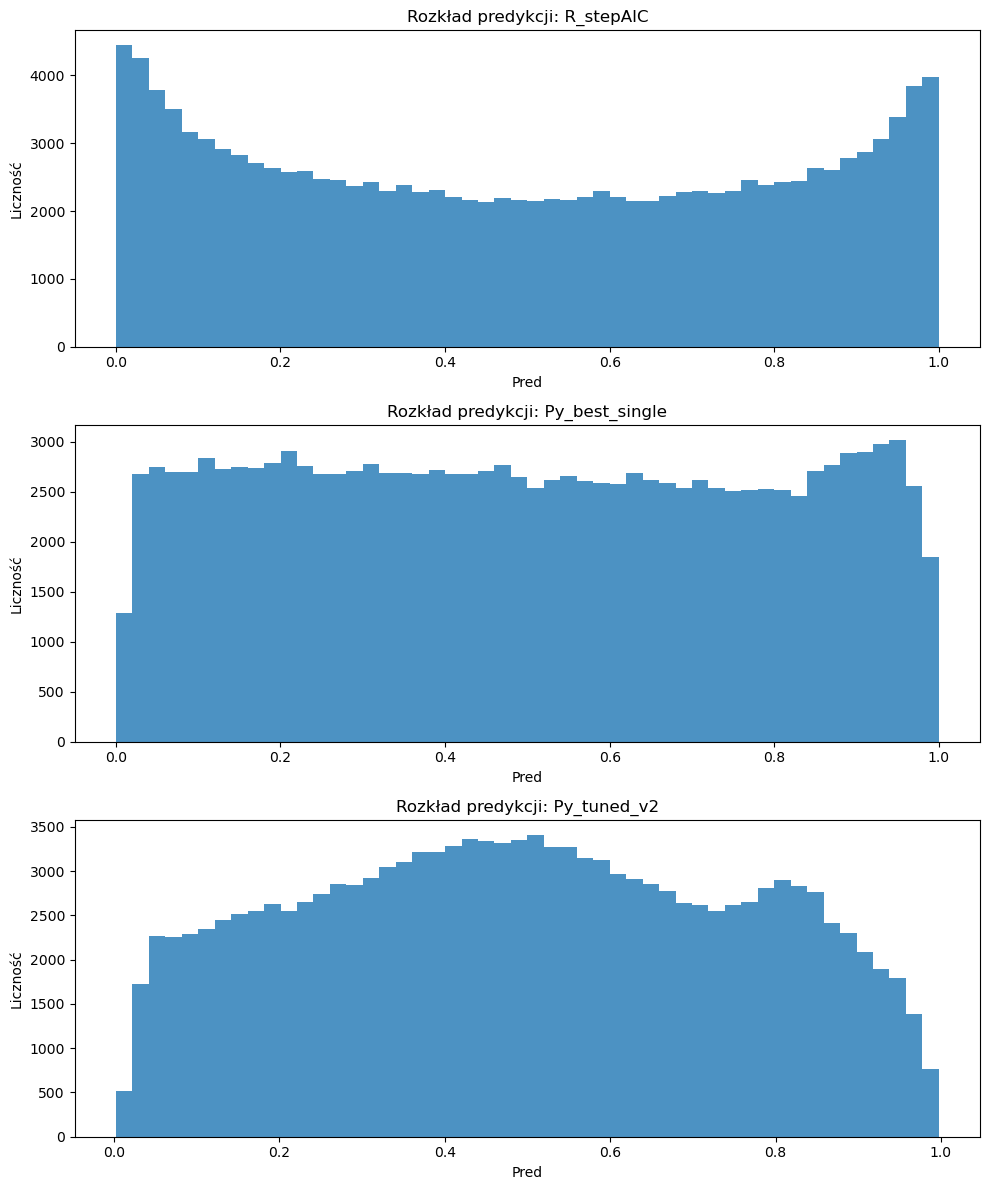

In [9]:
fig, axes = plt.subplots(len(merged.columns[1:]), 1, figsize=(10, 4 * len(merged.columns[1:])))
if len(merged.columns[1:]) == 1:
    axes = [axes]

for ax, col in zip(axes, merged.columns[1:]):
    ax.hist(merged[col], bins=50, alpha=0.8)
    ax.set_title(f"Rozkład predykcji: {col}")
    ax.set_xlabel("Pred")
    ax.set_ylabel("Liczność")

plt.tight_layout()
plt.show()